In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import seaborn as sns

In [3]:
data = pd.read_csv('Datasets/Folds.csv')
print(data.head(2), "\n")
print(data.info(), "\n")
print(data.describe(), "\n")

      AT      V       AP     RH      PE
0   8.34  40.77  1010.84  90.01  480.48
1  23.64  58.49  1011.40  74.20  445.75 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB
None 

                AT            V           AP           RH           PE
count  9568.000000  9568.000000  9568.000000  9568.000000  9568.000000
mean     19.651231    54.305804  1013.259078    73.308978   454.365009
std       7.452473    12.707893     5.938784    14.600269    17.066995
min       1.810000    25.360000   992.890000    25.560000   420.260000
25%      13.510000    41.740000  1009.100000    63.327500   439.750000
50%      20.345000    52.080000  1012.

In [4]:
data.corr()["PE"].sort_values(ascending = False) #Correlacion entre la variable de salida y las variables de entrada

PE    1.000000
AP    0.518429
RH    0.389794
V    -0.869780
AT   -0.948128
Name: PE, dtype: float64

La variable que más aporta o qué más relación tiene con PE es AP

<Axes: >

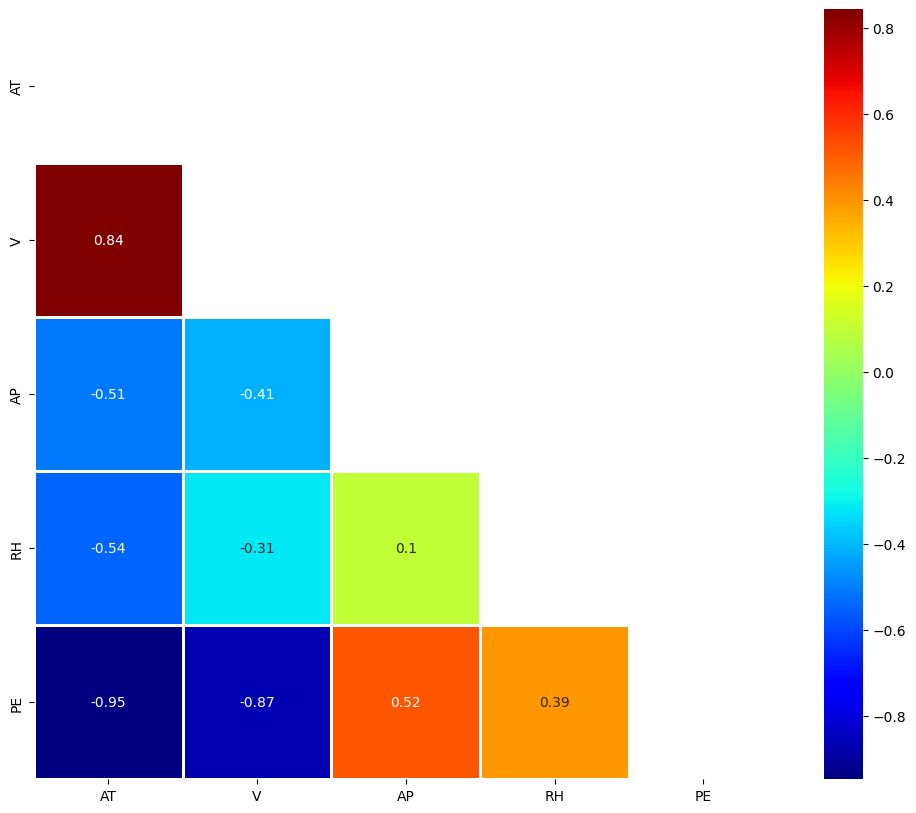

In [5]:
plt.figure(figsize=(12, 10))
mask = np.zeros_like(data.corr(), dtype=np.bool_) #Crea una mascara para la parte superior del heatmap
mask[np.triu_indices_from(mask)] = True 
sns.heatmap(data = data.corr(), cmap = "jet", annot = True, linewidths = 1, linecolor = "white", mask = mask)

#Esto para una mejor visualizacion de las correlaciones entre las variables

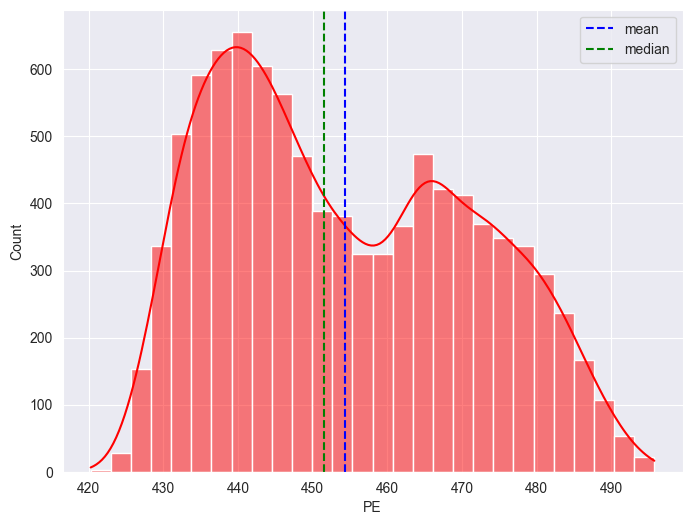

In [6]:
sns.set_style("darkgrid")
plt.figure(figsize=(8, 6))
sns.histplot(data, x = "PE", color = "red",kde = True) #Histograma de la distribucion de la variable PE
plt.axvline(data["PE"].mean(), color = "blue", linestyle = "--", label = "mean") #Muetra la media
plt.axvline(data["PE"].median(), color = "green", linestyle = "--", label = "median") #Muestra la mediana
plt.legend()
plt.show()


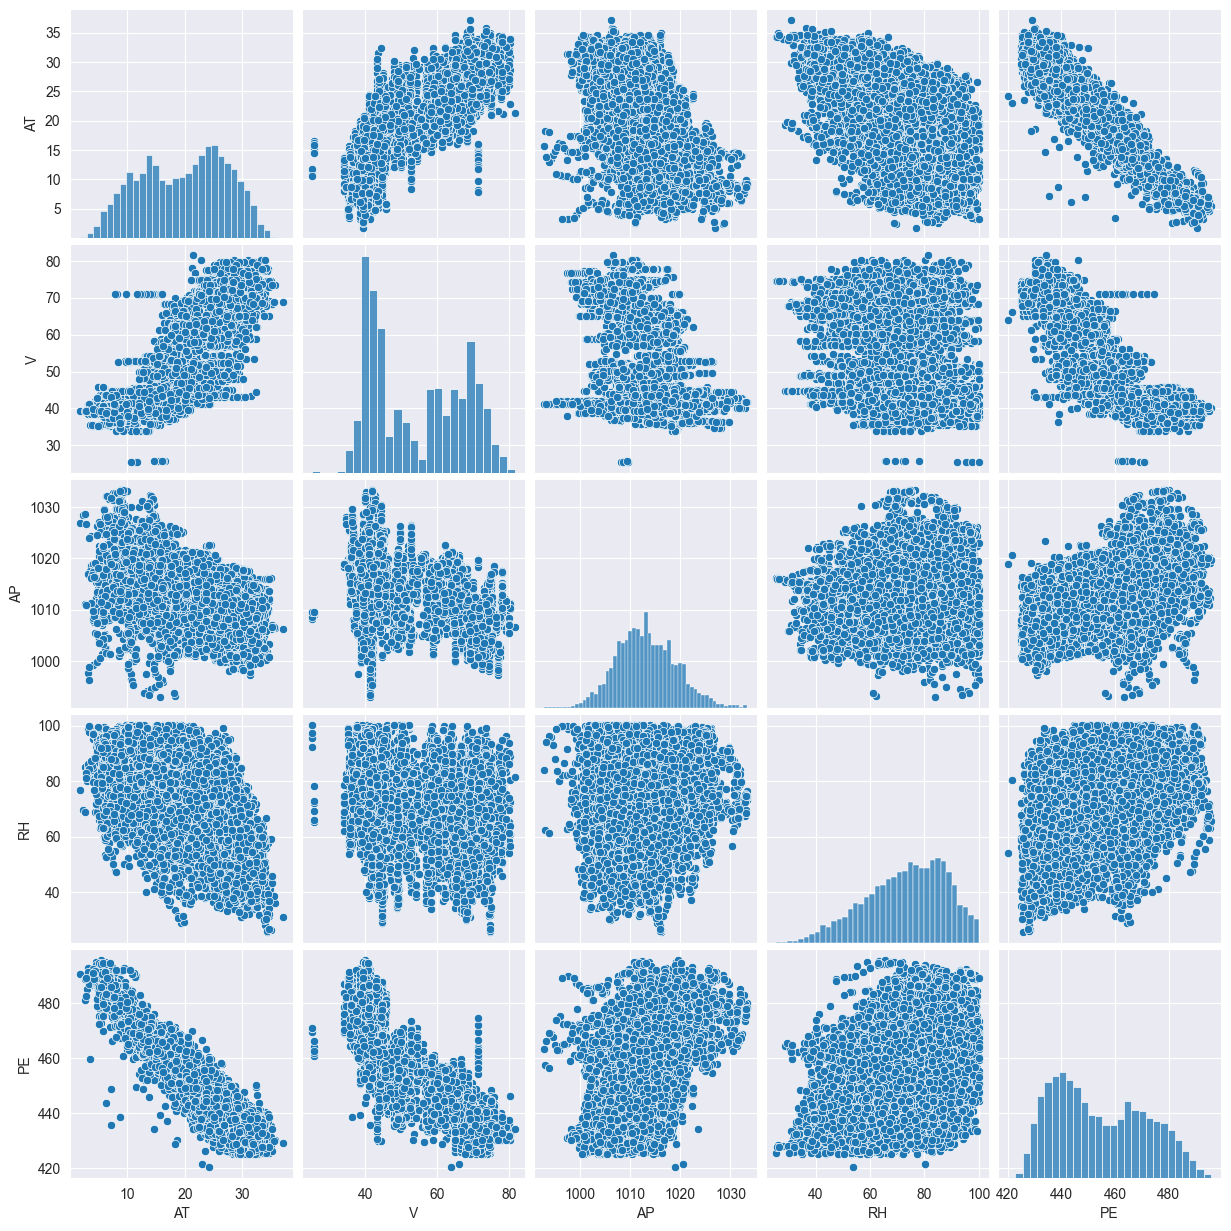

In [7]:
sns.pairplot(data)
plt.show()

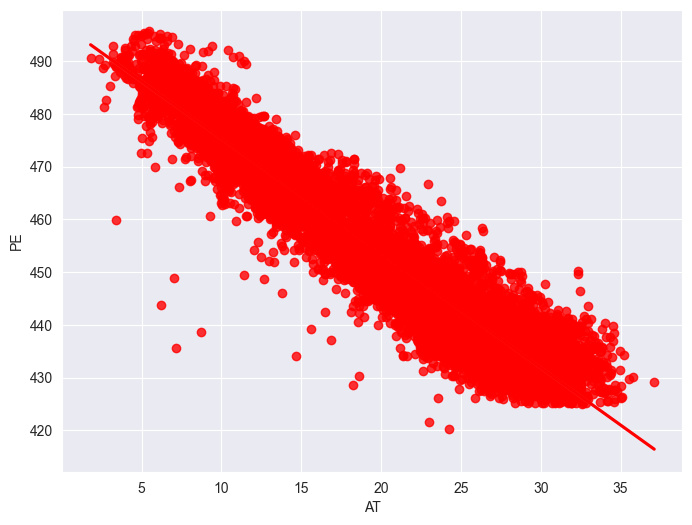

In [8]:
plt.figure(figsize=(8, 6))
sns.regplot(data, x = "AT", y = "PE", color = "red")
plt.show()


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping #Detención anticipada

In [21]:
rna = Sequential() #Se crea el objeto 
rna.add(Dense(12, activation = "relu")) #Capa de entrada
rna.add(Dense(6, activation = "relu")) #Capa oculta
rna.add(Dense(1)) #Capa de salida

rna.compile(optimizer = "adam", loss = "mean_squared_error", metrics = ["mse"]) #Compilacion del modelo

In [22]:
import sklearn
from sklearn.model_selection import train_test_split

In [38]:
x = data.drop(columns = ["PE"], axis=1).values
y = data["PE"].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2 , random_state = 42)

In [39]:
from sklearn.preprocessing import StandardScaler

In [40]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test) #Se escalan los datos de entrada

y_train = scaler.fit_transform(y_train.reshape(-1, 1)) 
y_test = scaler.transform(y_test.reshape(-1,1)) #Se escalan los datos de salida

In [41]:
historia = rna.fit(x_train, y_train, 
                   epochs = 100, 
                   batch_size = 32, 
                   validation_data = (x_test, y_test), callbacks = EarlyStopping(monitor ="val_loss", patience = 4)) 

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0569 - mse: 0.0569 - val_loss: 0.0533 - val_mse: 0.0533
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0555 - mse: 0.0555 - val_loss: 0.0535 - val_mse: 0.0535
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0579 - mse: 0.0579 - val_loss: 0.0536 - val_mse: 0.0536
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0578 - mse: 0.0578 - val_loss: 0.0543 - val_mse: 0.0543
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0536 - mse: 0.0536 - val_loss: 0.0534 - val_mse: 0.0534


# TENGO HAMBRE DIO MIO #

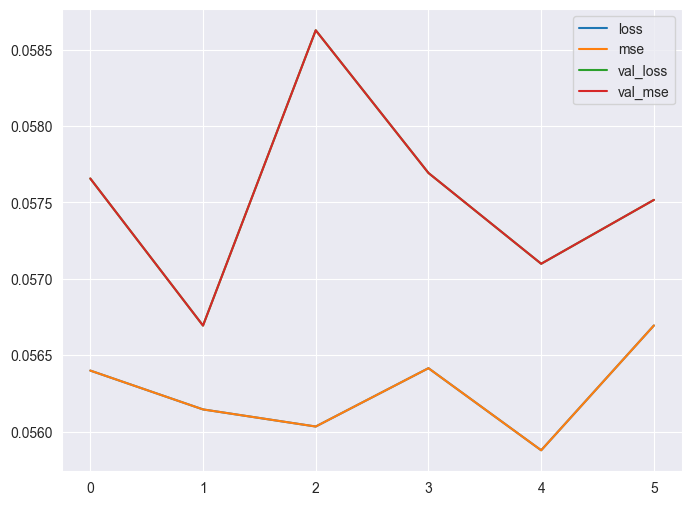

In [35]:
pd.DataFrame(historia.history).plot(figsize = (8,6))
plt.show()

In [42]:
rna.evaluate(x_test, y_test) #Evaluacion del modelo

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0523 - mse: 0.0523


[0.05339684709906578, 0.05339684709906578]

In [43]:
y_pred = rna.predict(x_test)

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


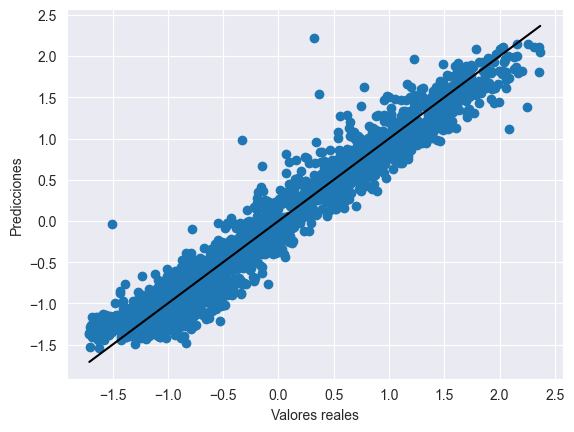

In [44]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color = "black")
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.show()

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("R2 Score: ", r2_score(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test, y_pred))
print("MSE: ", mean_squared_error(y_test, y_pred))

R2 Score:  0.9411578809480168
MAE:  0.18697276492742498
MSE:  0.057880213978657016
